# The exact affine spectrum as a calibration of Benettin's algorithm and of direct multiplication

This notebook replaces Fig. 3 of the manuscript *Exact Lyapunov spectra of affine cellular automata and the parity rule on networks* with a convergence study, and answers paragraph 3 of referee 2. The question there is what a numerical Lyapunov routine is worth when the answer is known in closed form. The answer given here is that the exact spectrum *calibrates* the numerics: it tells us how long Benettin's algorithm needs before its running average is trustworthy, and it tells us which exponents the direct-multiplication route of Vispoel et al. (2024) can resolve at all.

Everything is computed for rule 150 on a periodic ring of $N = 101$ cells unless stated. The Jacobian is the constant circulant matrix of Eq. (7), built by `lyapunov.jacobian.eca_jacobian`; the exact spectrum is Eq. (11), $\Lambda_k = \ln|1 + 2\cos(2\pi k/N)|$, from `lyapunov.benettin.closed_form_spectrum`. Benettin's algorithm and the unscaled direct method are `benettin_running_average` and `direct_multiplication_unscaled` in the same module. All arithmetic is float64. Nothing in this notebook is typed in by hand: every number quoted in a text cell is printed by the code cell beneath it, and the final cell asserts the lot against an independent reimplementation.

Runtime is about one minute. The BLAS thread count is pinned to one before numpy is imported: multithreaded QR on matrices this small is several times slower and, more importantly, changes the rounding pathway and hence the last digits of the slowest-converging exponents.

In [1]:
import os
for var in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ[var] = "1"          # before numpy is imported: speed and reproducibility

import sys, time, json
from pathlib import Path
import numpy as np
import scipy.linalg as sla
import matplotlib.pyplot as plt
from IPython.display import display

from lyapunov.jacobian import eca_jacobian
from lyapunov.spectra import eca_lyapunov_spectrum, eca_eigenvalues, eca_mle
from lyapunov.benettin import (closed_form_spectrum, benettin_running_average,
                               direct_multiplication_unscaled, precision_floor)

REPO = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(REPO / "figures"))
import _style                       # the repo's figure conventions: style + save to output/
_style.setup_style()

def save_figure(fig, stem):
    # Save through the repo's helper (PDF into output/); return the repo-relative path.
    return _style.save(fig, stem).relative_to(REPO).as_posix()

# Fixed, colour-blind-safe series colours (Okabe-Ito), assigned in this order throughout.
C = ["#D55E00", "#0072B2", "#009E73", "#CC79A7", "#E69F00"]
BLACK = _style.LINE_BLACK

RULE, N = 150, 101
J = eca_jacobian(RULE, N)
exact = closed_form_spectrum(RULE, N)          # Eq. (11), sorted descending
T_ALL = [25, 50, 100, 200, 400, 800, 1600, 3200]
t_start = time.time()
print(f"rule {RULE}, N = {N}; J is {J.shape[0]} x {J.shape[1]} with {int(J.sum())} nonzero entries;"
      f" symmetric: {np.array_equal(J, J.T)}")

rule 150, N = 101; J is 101 x 101 with 303 nonzero entries; symmetric: True


## 1. The exact spectrum

For rule 150 the gradient is $(1, 1, 1)$, so the Jacobian is the adjacency matrix of the ring plus the identity. It is circulant, hence normal, and its eigenvalues are $\lambda_k = 1 + 2\cos(2\pi k/N)$. The Lyapunov spectrum is $\Lambda_k = \ln|\lambda_k|$, Eq. (11), with no trajectory and no limit.

Three facts about this spectrum drive everything that follows. The maximal exponent is exactly $\ln 3$. Fifty of the 101 exponents are finite and negative, which contradicts the statement in Vispoel et al., Section 5, that the exponents of a cellular automaton are either positive or $-\infty$: for an affine rule a defect can shrink geometrically without vanishing. And consecutive singular values are close together: the ratio of the two largest is 0.9987, and the median of all consecutive ratios is about 0.9994. The second number needs care. On an odd ring the modes $k$ and $N - k$ have the same eigenvalue, so the spectrum consists of 50 exactly degenerate pairs plus the singleton $\ln 3$, half of the consecutive ratios are exactly 1, and the median is simply $(1 + 0.9987)/2$. The ratios between *distinct* singular values range from 0.49 to 0.9987 with a median of 0.955. The spectrum is dense at the top, where the gaps close as $1/N^2$, and near the middle it interleaves eigenvalues of opposite sign with nearly equal modulus. Both features set the horizon Benettin's algorithm needs.

MLE                   = 1.098612288668   ln 3 = 1.098612288668   difference = 0.0e+00
finite exponents      = 101 of 101
finite and negative   = 50 of 101
smallest exponent     = -3.3326
ratio sigma_2/sigma_1 = 0.9987
median of all ratios  = 0.9994
ratios exactly 1      = 50 of 100 (degenerate pairs k, N - k)
(1 + top ratio) / 2   = 0.9994
distinct-gap ratios   : max 0.9987, median 0.955, min 0.49
around the median (index, exponent, sign of lambda): (49, +0.0306, +), (50, +0.0306, +), (51, -0.0010, -), (52, -0.0010, -)


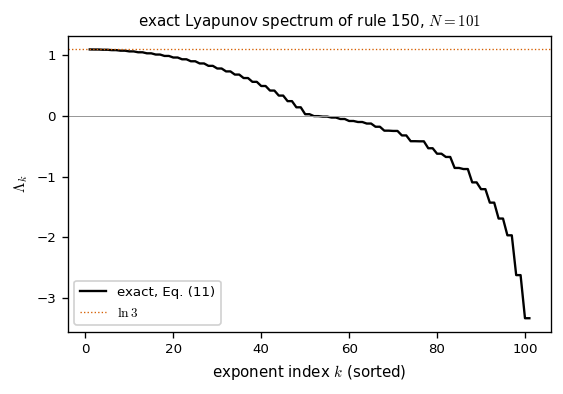

In [2]:
sv = np.exp(exact)
ratios = sv[1:] / sv[:-1]
n_neg = int(np.sum(exact < 0))
n_finite = int(np.sum(np.isfinite(exact)))
print(f"MLE                   = {exact[0]:.12f}   ln 3 = {np.log(3):.12f}   "
      f"difference = {abs(exact[0] - np.log(3)):.1e}")
print(f"finite exponents      = {n_finite} of {N}")
print(f"finite and negative   = {n_neg} of {N}")
print(f"smallest exponent     = {exact[-1]:.4f}")
print(f"ratio sigma_2/sigma_1 = {ratios[0]:.4f}")
print(f"median of all ratios  = {np.median(ratios):.4f}")
n_pairs = int(np.sum(np.abs(ratios - 1) < 1e-12))
gaps = ratios[np.abs(ratios - 1) > 1e-12]
print(f"ratios exactly 1      = {n_pairs} of {len(ratios)} (degenerate pairs k, N - k)")
print(f"(1 + top ratio) / 2   = {(1 + ratios[0]) / 2:.4f}")
print(f"distinct-gap ratios   : max {gaps.max():.4f}, median {np.median(gaps):.3f}, min {gaps.min():.2f}")
lam = eca_eigenvalues(RULE, N).real          # J is symmetric, so its eigenvalues are real
lam_sorted = lam[np.argsort(-np.abs(lam))]
print("around the median (index, exponent, sign of lambda):",
      ", ".join(f"({i}, {exact[i]:+.4f}, {'+' if lam_sorted[i] > 0 else '-'})" for i in range(49, 53)))

fig, ax = plt.subplots(figsize=(5.2, 3.2))
k_idx = np.arange(1, N + 1)
ax.plot(k_idx, exact, "-", color=BLACK, lw=1.4, label="exact, Eq. (11)")
ax.axhline(np.log(3), color=C[0], lw=0.8, ls=":", label=r"$\ln 3$")
ax.axhline(0, color="0.6", lw=0.6)
ax.set_xlabel(r"exponent index $k$ (sorted)"); ax.set_ylabel(r"$\Lambda_k$")
ax.set_title(f"exact Lyapunov spectrum of rule {RULE}, $N = {N}$")
ax.legend(loc="lower left", framealpha=0.9)
plt.show()

## 2. Benettin from the identity

Benettin's algorithm propagates an orthonormal frame $Q$ with $J Q = Q' R$ and averages $\ln|R_{kk}|$ over $T$ steps. The manuscript's Fig. 3 started from $Q^0 = I$ and accumulated from the first step. Here that run is repeated at horizons from $T = 25$ to $3200$, with the running average read off at each horizon in a single pass, and the error against the exact spectrum is shown for $k = 1$, $10$, $51$ (the median) and $101$.

The error decays as $1/T$: for $T \geq 400$ the fitted log-log slopes are within 0.1 of $-1$, and the error halves with each doubling of $T$, exactly so for the bottom exponent from the start and for the top exponent once its frame vector has aligned (the ratio of successive errors rises from 1.8 to 2.0 over the first thousand steps, because the top gap of 0.9987 per step is the slowest to resolve, which is why the slope over all $T$ is nearer $-0.9$ for $k = 1$). This is not a flaw of the algorithm. The frame starts misaligned with the singular directions, the first few dozen $\ln|R_{kk}|$ are therefore wrong, and a running average carries that fixed transient divided by $T$ for ever. The median exponent shows the same $1/T$ trend with a second effect superposed, which Section 3 isolates.

absolute error of the running average, Q0 = I, no burn-in
     T        k = 1 (top)            k = 10   k = 51 (median)  k = 101 (bottom)
    25           5.35e-02          4.21e-01          2.35e-01          7.84e-02
    50           3.02e-02          2.54e-01          2.52e-01          3.92e-02
   100           1.68e-02          1.42e-01          1.49e-01          1.96e-02
   200           9.28e-03          7.18e-02          8.65e-02          9.80e-03
   400           5.07e-03          3.55e-02          2.71e-02          4.90e-03
   800           2.74e-03          1.78e-02          2.05e-05          2.45e-03
  1600           1.43e-03          8.88e-03          2.17e-04          1.23e-03
  3200           7.21e-04          4.44e-03          1.08e-04          6.13e-04

error(T) / error(2T): a ratio of 2 is a 1/T decay
  k = 1 (top)       1.77  1.79  1.81  1.83  1.85  1.91  1.99   log-log slope -0.88 (all T), -0.94 (T >= 400)
  k = 10            1.66  1.79  1.98  2.02  2.00  2.00  2.00  

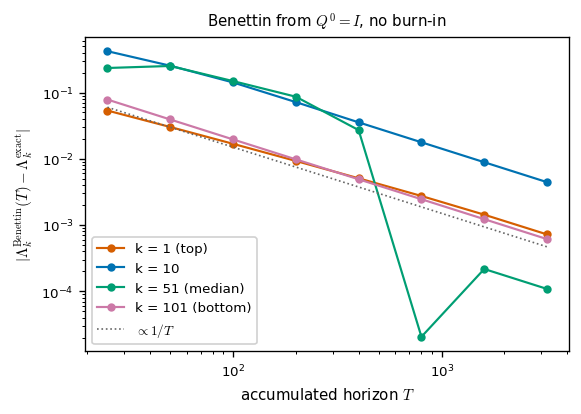

In [3]:
KS = {1: "k = 1 (top)", 10: "k = 10", 51: "k = 51 (median)", 101: "k = 101 (bottom)"}
no_burn = benettin_running_average(J, max(T_ALL), burn=0, checkpoints=T_ALL)
err_no_burn = {k: np.array([abs(no_burn[T][k - 1] - exact[k - 1]) for T in T_ALL]) for k in KS}

print("absolute error of the running average, Q0 = I, no burn-in")
print("     T " + "".join(f"{KS[k]:>18s}" for k in KS))
for i, T in enumerate(T_ALL):
    print(f"{T:6d} " + "".join(f"{err_no_burn[k][i]:18.2e}" for k in KS))
print("\nerror(T) / error(2T): a ratio of 2 is a 1/T decay")
Tarr = np.array(T_ALL, float)
slope, slope_late = {}, {}
late = Tarr >= 400
for kk in (1, 10, 101):
    r = err_no_burn[kk][:-1] / err_no_burn[kk][1:]
    slope[kk] = np.polyfit(np.log(Tarr), np.log(err_no_burn[kk]), 1)[0]
    slope_late[kk] = np.polyfit(np.log(Tarr[late]), np.log(err_no_burn[kk][late]), 1)[0]
    print(f"  {KS[kk]:16s} " + " ".join(f"{x:5.2f}" for x in r)
          + f"   log-log slope {slope[kk]:+.2f} (all T), {slope_late[kk]:+.2f} (T >= 400)")

fig, ax = plt.subplots(figsize=(5.2, 3.4))
for i, kk in enumerate(KS):
    ax.loglog(Tarr, err_no_burn[kk], "o-", color=C[i], ms=4, label=KS[kk])
ax.loglog(Tarr, 1.5 / Tarr, ":", color="0.4", lw=1, label=r"$\propto 1/T$")
ax.set_xlabel(r"accumulated horizon $T$"); ax.set_ylabel(r"$|\Lambda_k^{\rm Benettin}(T) - \Lambda_k^{\rm exact}|$")
ax.set_title(r"Benettin from $Q^0 = I$, no burn-in")
ax.legend(loc="lower left", framealpha=0.9)
plt.show()

## 3. Burn-in, and the horizon a dense spectrum needs

The transient is removed by discarding the first 200 QR steps before accumulation starts. With that burn-in the top and bottom exponents are correct to about $10^{-3}$ or better at $T = 200$. The median exponent is not: it is still off by $3 \times 10^{-2}$ at $T = 200$ and $9 \times 10^{-3}$ at $T = 2000$. The reason is in Section 1, and it is not a slow drift but a late swap. The error at $T = 200$ is exactly $\ln(\sigma_{51}/\sigma_{53}) = 0.0316$, the log gap to the neighbouring pair, whose eigenvalue has the opposite sign and a modulus only 3 % smaller. The 51st frame vector sits in that neighbouring eigenpair, so its instantaneous $\ln|R_{kk}|$ is the neighbour's exponent, and only between roughly step 700 and step 900 does it swap into the correct pair; from then on the instantaneous value is exact and the running average carries the accumulated transient divided by $T$, which is the $9 \times 10^{-3}$ at $T = 2000$. A 200-step burn-in fixes the ends of the spectrum, where the ordering is resolved quickly, and is too short for the interior, where the modulus ordering of eigenvalues of opposite sign takes far longer to sort out than the gap ratio alone suggests.

The first figure below is saved as `output/convergence_benettin_rule150.pdf`. Dashed lines are the no-burn-in run of Section 2, solid lines the burn-in run.

burn-in of 200 steps, then accumulate
  T = 200 : top 8.7e-04   bottom 6.2e-15   median (k = 51) 3.2e-02
  T = 2000: top 2.2e-04   bottom 1.1e-13   median (k = 51) 8.8e-03
log gap from the median pair to the next pair, ln(sigma_51/sigma_53) = 0.0316; eigenvalue signs + and -
median error at T = 200 minus that log gap: +7.3e-04


instantaneous error of the median frame vector at steps 200, 400, 600, 800, 1000, 1200: -0.0337 -0.0317 -0.0316 -0.0011 -0.0000 -0.0000
first step at which it is within 1e-3 of exact and stays there: 918
accumulated instantaneous error over steps 201..1200: -17.654; divided by T = 2000: 8.83e-03   (observed running-average error at T = 2000: 8.83e-03)


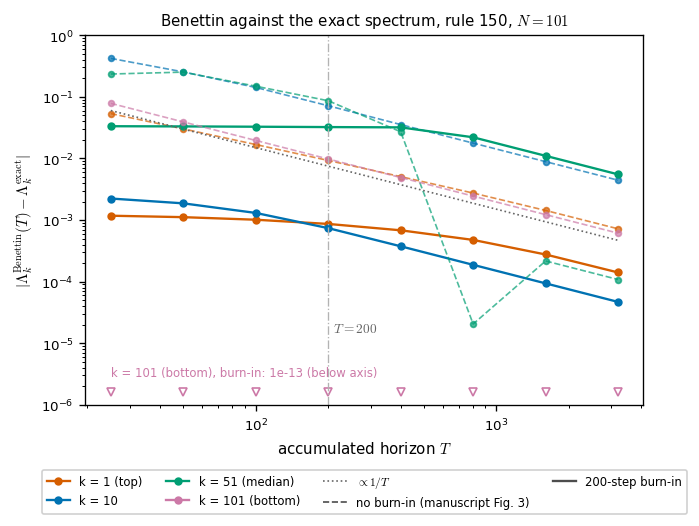

saved output/convergence_benettin_rule150.pdf


In [4]:
BURN = 2 * 100
T_BURN = sorted(set(T_ALL) | {2000})
burn = benettin_running_average(J, max(T_BURN), burn=BURN, checkpoints=T_BURN)
err_burn = {k: np.array([abs(burn[T][k - 1] - exact[k - 1]) for T in T_ALL]) for k in KS}
e200, e2000 = np.abs(burn[200] - exact), np.abs(burn[2000] - exact)
print(f"burn-in of {BURN} steps, then accumulate")
print(f"  T = 200 : top {e200[0]:.1e}   bottom {e200[-1]:.1e}   median (k = 51) {e200[50]:.1e}")
print(f"  T = 2000: top {e2000[0]:.1e}   bottom {e2000[-1]:.1e}   median (k = 51) {e2000[50]:.1e}")
log_gap = float(np.log(sv[50] / sv[52]))
print(f"log gap from the median pair to the next pair, ln(sigma_51/sigma_53) = {log_gap:.4f}; "
      f"eigenvalue signs {'+' if lam_sorted[50] > 0 else '-'} and {'+' if lam_sorted[52] > 0 else '-'}")
print(f"median error at T = 200 minus that log gap: {e200[50] - log_gap:+.1e}")

# Instantaneous ln|R_kk| of the median frame vector (k = 51), step by step from Q0 = I.
Q_probe, inst = np.eye(N), []
for t in range(1, 1201):
    Q_probe, R_probe = np.linalg.qr(J @ Q_probe)
    inst.append(np.log(abs(R_probe[50, 50])) - exact[50])
inst = np.array(inst)
swap_step = int(np.max(np.where(np.abs(inst) >= 1e-3)[0])) + 2   # last step still off, plus one
print("instantaneous error of the median frame vector at steps 200, 400, 600, 800, 1000, 1200:",
      " ".join(f"{inst[t - 1]:+.4f}" for t in (200, 400, 600, 800, 1000, 1200)))
print(f"first step at which it is within 1e-3 of exact and stays there: {swap_step}")
transient = float(np.sum(inst[BURN:]))          # accumulated instantaneous error over steps 201..1200
print(f"accumulated instantaneous error over steps {BURN + 1}..1200: {transient:+.3f}; divided by T = 2000: "
      f"{abs(transient) / 2000:.2e}   (observed running-average error at T = 2000: {e2000[50]:.2e})")

Y_MIN = 1e-6
fig, ax = plt.subplots(figsize=(6.0, 4.0))
for i, kk in enumerate(KS):
    ax.loglog(Tarr, err_no_burn[kk], "o--", color=C[i], ms=3.5, lw=1.0, alpha=0.7)
    e = err_burn[kk]
    on = e >= Y_MIN
    ax.loglog(Tarr[on], e[on], "o-", color=C[i], ms=4, lw=1.4, label=KS[kk])
    if not on.all():   # machine-precision errors: mark at the axis floor, pointing down
        ax.loglog(Tarr[~on], np.full((~on).sum(), Y_MIN * 1.6), "v", color=C[i], ms=5, mfc="none")
        ax.text(Tarr[~on][0], Y_MIN * 2.6, f"{KS[kk]}, burn-in: {e.max():.0e} (below axis)",
                color=C[i], fontsize=7, va="bottom")
ax.loglog(Tarr, 1.5 / Tarr, ":", color="0.4", lw=1, label=r"$\propto 1/T$")
ax.plot([], [], "--", color="0.3", lw=1.0, label="no burn-in (manuscript Fig. 3)")
ax.plot([], [], "-", color="0.3", lw=1.4, label=f"{BURN}-step burn-in")
ax.axvline(200, color="0.7", lw=0.8, ls="-.")
ax.text(210, 1.5e-5, r"$T = 200$", color="0.4", fontsize=8)
ax.set_ylim(Y_MIN, 1); ax.set_xlabel(r"accumulated horizon $T$")
ax.set_ylabel(r"$|\Lambda_k^{\rm Benettin}(T) - \Lambda_k^{\rm exact}|$")
ax.set_title(f"Benettin against the exact spectrum, rule {RULE}, $N = {N}$")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=4, fontsize=7, framealpha=0.9)
display(fig)
print("saved", save_figure(fig,"convergence_benettin_rule150"))

The alignment time depends on $N$, because the spectral gaps shrink as the spectrum fills in. A single index such as the median exponent is the wrong thing to track across $N$: its local gap varies non-monotonically with $N$ and gives a misleading curve. The robust measure is the fraction of the whole spectrum that lies within $10^{-2}$ of the exact value. For $N = 31$, $61$, $101$ and $201$ this fraction at $T = 200$ is 1.00, 0.93, 0.91 and 0.81; at $T = 800$ it is 1.00, 1.00, 0.98 and 0.94; at $T = 3200$ it is 1.00, 1.00, 1.00 and 0.99. The required horizon grows with $N$.

This is the positive result, and it should be read as a calibration rather than as a criticism of the algorithm. The exact spectrum tells us what horizon a dense spectrum needs, and non-affine rules have dense spectra too: the same alignment rates apply to any rule whose singular values cluster, whether or not the Jacobian is constant. The figure is saved as `output/convergence_horizon_vs_N.pdf`.

One caveat on precision. For $N = 201$ a dozen exponents sit within $2 \times 10^{-3}$ of the $10^{-2}$ threshold at $T = 800$, so the last digit of that fraction depends on the rounding pathway of the QR factorisation (in practice, on the number of BLAS threads). The trend does not.

fraction of the spectrum within 0.01 of the exact value, 200-step burn-in
     T    N =  31   N =  61   N = 101   N = 201
    25       1.00      0.93      0.90      0.63
    50       1.00      0.93      0.90      0.67
   100       1.00      0.93      0.91      0.73
   200       1.00      0.93      0.91      0.81
   400       1.00      0.97      0.92      0.88
   800       1.00      1.00      0.98      0.95
  1600       1.00      1.00      0.98      0.97
  3200       1.00      1.00      1.00      0.99



N = 201, T = 800: 13 of 201 exponents have an error within 2e-3 of the threshold


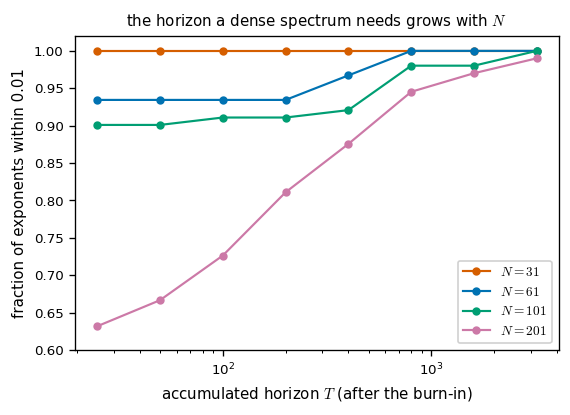

saved output/convergence_horizon_vs_N.pdf


In [5]:
N_LIST = [31, 61, 101, 201]
TOL = 1e-2
frac = {}
for n in N_LIST:
    Jn, exn = eca_jacobian(RULE, n), closed_form_spectrum(RULE, n)
    rn = benettin_running_average(Jn, max(T_ALL), burn=BURN, checkpoints=T_ALL)
    frac[n] = np.array([np.mean(np.abs(rn[T] - exn) < TOL) for T in T_ALL])

print(f"fraction of the spectrum within {TOL:g} of the exact value, {BURN}-step burn-in")
print("     T " + "".join(f"   N = {n:3d}" for n in N_LIST))
for i, T in enumerate(T_ALL):
    print(f"{T:6d} " + "".join(f"{frac[n][i]:10.2f}" for n in N_LIST))
rn = benettin_running_average(eca_jacobian(RULE, 201), 800, burn=BURN, checkpoints=[800])
e = np.abs(rn[800] - closed_form_spectrum(RULE, 201))
print(f"\nN = 201, T = 800: {int(np.sum((e > 0.008) & (e < 0.012)))} of 201 exponents have an error within 2e-3 of the threshold")

fig, ax = plt.subplots(figsize=(5.2, 3.4))
for i, n in enumerate(N_LIST):
    ax.semilogx(Tarr, frac[n], "o-", color=C[i], ms=4, label=f"$N = {n}$")
ax.set_ylim(0.6, 1.02); ax.set_xlabel(r"accumulated horizon $T$ (after the burn-in)")
ax.set_ylabel(f"fraction of exponents within {TOL:g}")
ax.set_title("the horizon a dense spectrum needs grows with $N$")
ax.legend(loc="lower right", framealpha=0.9)
display(fig)
print("saved", save_figure(fig,"convergence_horizon_vs_N"))

## 4. Direct multiplication

Vispoel et al. (2024) compute the spectrum from the unscaled product: $Y^0 = I$, $Y^{t+1} = J\,Y^t$ (their Eqs. 8 to 10), then the eigenvalues $\mu_k$ of $Y^T (Y^T)^\top$ and $\Lambda_k = \ln \mu_k / (2T)$ (their Eq. 35). The cell below does exactly that in float64, with no rescaling, and compares the sorted result with the exact spectrum for $T = 50$, $100$, $200$ and $300$.

The eigenvalues of $Y Y^\top$ are $\sigma_k^{2T}$ and span from $\sigma_{\max}^{2T}$ down to $\sigma_{\min}^{2T}$. Double precision carries them all with an absolute error of order $\varepsilon\,\sigma_{\max}^{2T}$, with $\varepsilon = 2.2 \times 10^{-16}$, so any $\sigma_k^{2T}$ below that is indistinguishable from rounding noise. Dividing the logarithm by $2T$ gives the precision floor
$$\Lambda_{\rm floor}(T) = \ln \sigma_{\max} + \frac{\ln \varepsilon}{2T},$$
and no exponent below it can be resolved. The rounding noise is spread on both sides of zero, so the unresolved eigenvalues come in two kinds. The positive ones are reported at the floor, within a few hundredths of it; this is the plateau in the figure. The negative ones have no logarithm, so the method returns no number at all for them (the cell prints how many, between a third and a half of the spectrum), and the curve is simply absent there. Nothing below the floor is a result of the method. The floor *rises* with $T$: the number of exponents resolved above it falls from 31 at $T = 50$ to 21, 15 and 11 at $T = 100$, $200$ and $300$. More timesteps make this method worse. The figure is saved as `output/convergence_direct_multiplication.pdf`.

T =  50: floor 0.738, MLE reported 1.098612288668; of 101 exponents 31 resolved above the floor, 37 at the floor (all within 0.044 of it), 33 with a negative eigenvalue and no result
T = 100: floor 0.918, MLE reported 1.098612288668; of 101 exponents 21 resolved above the floor, 47 at the floor (all within 0.029 of it), 33 with a negative eigenvalue and no result
T = 200: floor 1.009, MLE reported 1.098612288668; of 101 exponents 15 resolved above the floor, 47 at the floor (all within 0.014 of it), 39 with a negative eigenvalue and no result
T = 300: floor 1.039, MLE reported 1.098612288668; of 101 exponents 11 resolved above the floor, 42 at the floor (all within 0.013 of it), 48 with a negative eigenvalue and no result
resolved counts as T rises: [31, 21, 15, 11]


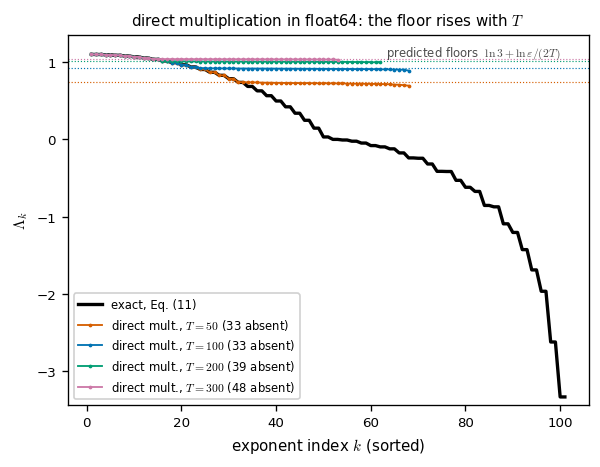

saved output/convergence_direct_multiplication.pdf


In [6]:
T_DIRECT = [50, 100, 200, 300]
SIG_MAX = np.exp(exact[0])
direct, floors, resolved, n_negative, noise_dist = {}, {}, {}, {}, {}
for T in T_DIRECT:
    direct[T] = direct_multiplication_unscaled(J, T)          # nan where the eigenvalue is negative
    floors[T] = precision_floor(SIG_MAX, T)
    reported = direct[T][np.isfinite(direct[T])]
    resolved[T] = int(np.sum(reported > floors[T] + 0.02))
    n_negative[T] = int(np.isnan(direct[T]).sum())
    noise = reported[reported <= floors[T] + 0.02]              # positive rounding noise
    noise_dist[T] = float(np.abs(noise - floors[T]).max())
    print(f"T = {T:3d}: floor {floors[T]:.3f}, MLE reported {direct[T][0]:.12f}; of {N} exponents "
          f"{resolved[T]:2d} resolved above the floor, {len(noise):2d} at the floor (all within "
          f"{noise_dist[T]:.3f} of it), {n_negative[T]:2d} with a negative eigenvalue and no result")
print(f"resolved counts as T rises: {[resolved[T] for T in T_DIRECT]}")

fig, ax = plt.subplots(figsize=(5.6, 4.0))
ax.plot(k_idx, exact, "-", color=BLACK, lw=2.0, label="exact, Eq. (11)")
for i, T in enumerate(T_DIRECT):
    ax.plot(k_idx, direct[T], "-", marker=".", ms=2.5, color=C[i], lw=1.1,
            label=f"direct mult., $T = {T}$ ({n_negative[T]} absent)")
    ax.axhline(floors[T], color=C[i], lw=0.7, ls=":")
ax.text(N - 1, floors[T_DIRECT[-1]] + 0.04, r"predicted floors  $\ln 3 + \ln\varepsilon/(2T)$",
        ha="right", fontsize=7, color="0.3")
ax.set_ylim(exact[-1] - 0.1, exact[0] + 0.25); ax.set_xlabel(r"exponent index $k$ (sorted)")
ax.set_ylabel(r"$\Lambda_k$"); ax.set_title("direct multiplication in float64: the floor rises with $T$")
ax.legend(loc="lower left", fontsize=7, framealpha=0.9)
display(fig)
print("saved", save_figure(fig,"convergence_direct_multiplication"))

Beyond the floor there is the overflow. The largest eigenvalue of $Y Y^\top$ is $\sigma_{\max}^{2T} = 3^{2T}$, which exceeds the largest float64 (about $1.8 \times 10^{308}$) once $T > 323$. At $T = 324$ the entries of $Y Y^\top$ are still finite but its top eigenvalue is not, and one step later the entries overflow as well; the routine raises rather than returning infinities. Vispoel et al., Section 6, state $N = 1000$ and $T = 500$. For rule 150 at $T = 500$ the entries of $Y Y^\top$ would be of order $3^{1000} \approx 10^{477}$, far beyond float64, so the method as described cannot have produced their Fig. 18(c) without an undocumented rescaling.

If some rescaling was applied, the floor still stands, because it comes from the relative precision of the eigenvalues and not from their absolute size. The predicted floors at $T = 500$ are 1.063 for rule 150 and 0.657 for rules 60 and 90. The histograms in their Fig. 18 span 1.02 to 1.09 for rule 150, 0.61 to 0.69 for rule 90 and 0.002 to 0.013 for rule 60. The first two are consistent with the floor. The third is not consistent with either the floor or the exact spectrum, and rules 60 and 90 have the same limiting spectral density and the same MLE, $\ln 2$, so their Fig. 18(a) and 18(b) cannot both be correct regardless of method.

In [7]:
F64_MAX = np.finfo(np.float64).max
T_overflow = int(np.log(F64_MAX) / (2 * np.log(SIG_MAX)))
print(f"largest float64 = {F64_MAX:.3e}; 3^(2T) exceeds it beyond T = {T_overflow}")
print(f"T = {T_overflow}: all reported exponents finite: {bool(np.all(np.isfinite(direct_multiplication_unscaled(J, T_overflow))))}")
for T in (T_overflow + 1, T_overflow + 2):
    try:
        direct_multiplication_unscaled(J, T)
        print(f"T = {T}: no error (unexpected)")
    except OverflowError as err:
        print(f"T = {T}: OverflowError: {err}")
T_V, N_V = 500, 1000
print(f"\nVispoel et al. Section 6: N = {N_V}, T = {T_V}. Entries of Y Y^T ~ 3^(2T) = 3^{2 * T_V} "
      f"~ 10^{2 * T_V * np.log10(3):.0f}; float64 maximum ~ 10^{np.log10(F64_MAX):.0f}")

print(f"\npredicted floors at T = {T_V}:  rule 150: {precision_floor(3.0, T_V):.3f}   "
      f"rules 60 and 90: {precision_floor(2.0, T_V):.3f}")
print("Vispoel et al. Fig. 18 histogram ranges (read from their figure): "
      "rule 150: 1.02 to 1.09, rule 90: 0.61 to 0.69, rule 60: 0.002 to 0.013")

# Rules 60 and 90: same MLE, same limiting spectral density.
nn = 3001
s60, s90 = np.sort(eca_lyapunov_spectrum(60, nn)), np.sort(eca_lyapunov_spectrum(90, nn))
q = np.linspace(0.05, 0.95, 7)
print(f"\nMLE rule 60 = {eca_mle(60):.6f}, rule 90 = {eca_mle(90):.6f}, ln 2 = {np.log(2):.6f}")
print(f"quantiles of the finite spectra at N = {nn} (rule 60 / rule 90):")
for qq, a, b in zip(q, np.quantile(s60, q), np.quantile(s90, q)):
    print(f"  {qq:.2f}: {a:8.4f} / {b:8.4f}")
print(f"largest quantile difference: {np.max(np.abs(np.quantile(s60, q) - np.quantile(s90, q))):.1e}")

largest float64 = 1.798e+308; 3^(2T) exceeds it beyond T = 323
T = 323: all reported exponents finite: False
T = 324: OverflowError: Y Y^T overflows float64 at T = 324: its largest eigenvalue is sigma_max^(2T), so the unscaled method has no result beyond T = floor(ln(1.8e308) / (2 ln sigma_max)).
T = 325: OverflowError: Y Y^T overflows float64 at T = 325: its largest eigenvalue is sigma_max^(2T), so the unscaled method has no result beyond T = floor(ln(1.8e308) / (2 ln sigma_max)).

Vispoel et al. Section 6: N = 1000, T = 500. Entries of Y Y^T ~ 3^(2T) = 3^1000 ~ 10^477; float64 maximum ~ 10^308

predicted floors at T = 500:  rule 150: 1.063   rules 60 and 90: 0.657
Vispoel et al. Fig. 18 histogram ranges (read from their figure): rule 150: 1.02 to 1.09, rule 90: 0.61 to 0.69, rule 60: 0.002 to 0.013

MLE rule 60 = 0.693147, rule 90 = 0.693147, ln 2 = 0.693147
quantiles of the finite spectra at N = 3001 (rule 60 / rule 90):
  0.05:  -1.8457 /  -1.8457
  0.20:  -0.4799 /  -0.4799
  0.35

## 5. Why the eigenbasis makes QR a no-op

Take the adjacency matrix of the triangle $C_3$: singular values $(2, 1, 1)$, determinant $2$. From $Q^0 = I$ the first QR step gives $\mathrm{diag}|R| = (1.4142, 1.2247, 1.1547)$, which is not the singular values, although the product is exactly $2 = |\det J|$ (Benettin conserves the volume at every step; that is claim C6). From $Q^0$ equal to the eigenbasis the first step gives $(2, 1, 1)$, and so does every later step, with $R$ diagonal to machine precision: there is nothing left to orthogonalise. The same holds for rule 150 at $N = 101$, where the error from the eigenbasis is at machine precision at $T = 1$.

The conclusion is that for a constant normal Jacobian, Benettin's algorithm reduces to the eigendecomposition and is not needed. The QR steps do nothing but slowly rotate the identity into the eigenbasis, which is the transient of Sections 2 and 3.

In [8]:
A = np.array([[0, 1, 1], [1, 0, 1], [1, 1, 0]], dtype=float)
print("C3 adjacency: singular values", np.round(np.linalg.svd(A, compute_uv=False), 4),
      " |det| =", round(abs(np.linalg.det(A)), 4))
_, R = np.linalg.qr(A @ np.eye(3))
d = np.abs(np.diag(R))
print(f"from Q0 = I, step 1: diag|R| = {np.round(d, 4)},  product = {d.prod():.4f}")
w, X = np.linalg.eigh(A); X = X[:, np.argsort(-np.abs(w))]
Q = X.copy()
for t in range(1, 4):
    Q, R = np.linalg.qr(A @ Q)
    off = np.abs(R - np.diag(np.diag(R))).max()
    print(f"from the eigenbasis, step {t}: diag|R| = {np.round(np.abs(np.diag(R)), 4)},  max off-diagonal of R = {off:.1e}")

w, X = np.linalg.eigh(J.astype(float)); X = X[:, np.argsort(-np.abs(w))]
eig_start = benettin_running_average(J, 5, checkpoints=[1, 5], Q0=X)
eig_err = {T: float(np.max(np.abs(eig_start[T] - exact))) for T in (1, 5)}
print(f"\nrule {RULE}, N = {N}, from the eigenbasis: max |Lambda - exact| = {eig_err[1]:.1e} at T = 1, "
      f"{eig_err[5]:.1e} at T = 5")

C3 adjacency: singular values [2. 1. 1.]  |det| = 2.0
from Q0 = I, step 1: diag|R| = [1.4142 1.2247 1.1547],  product = 2.0000
from the eigenbasis, step 1: diag|R| = [2. 1. 1.],  max off-diagonal of R = 3.3e-16
from the eigenbasis, step 2: diag|R| = [2. 1. 1.],  max off-diagonal of R = 2.2e-16
from the eigenbasis, step 3: diag|R| = [2. 1. 1.],  max off-diagonal of R = 1.1e-16

rule 150, N = 101, from the eigenbasis: max |Lambda - exact| = 1.2e-14 at T = 1, 1.2e-14 at T = 5


## 6. Constant but not normal

Normality is what makes $\ln\sigma_k$ the right answer, and it is not automatic. Take the affine rule with gradient (left, self) $= (1, 1)$ on a line of four cells with fixed boundaries. Its Jacobian is lower bidiagonal with ones on and below the diagonal: every eigenvalue is $1$, the singular values are $(1.879, 1.532, 1, 0.347)$, and the true Lyapunov exponents are all $0$ because $J^t$ grows only polynomially. Reading off $\ln\sigma_k$ would claim a maximal exponent of $0.63$. Benettin's algorithm from the identity does converge to $0$, but slowly, as $\ln T / T$. The eigenbasis does not exist, since the matrix is defective, but the Schur basis does, and from it the algorithm is exact after a single step.

This is the justification for the manuscript's Eq. (7): $\Lambda_k = \ln|\lambda_k|$ in general, equal to $\ln\sigma_k$ only when $J$ is normal, which holds on periodic lattices because $J$ is circulant.

In [9]:
B = np.eye(4) + np.eye(4, k=-1)
svB = np.linalg.svd(B, compute_uv=False)
print("J =\n", B.astype(int))
print("eigenvalues     ", np.round(np.linalg.eigvals(B).real, 6))
print("singular values ", np.round(svB, 3), "  ln sigma_1 =", round(float(np.log(svB[0])), 3))
print("true exponents  ", [0, 0, 0, 0], " (J^t grows polynomially: max |J^t| =",
      int(np.abs(np.linalg.matrix_power(B, 20)).max()), "at t = 20)")
print("\nBenettin from Q0 = I")
print("      T     Lambda_1   Lambda_2   Lambda_3   Lambda_4    max|Lambda|")
bid = {}
for T in (10, 100, 1000, 10000):
    bid[T] = benettin_running_average(B, T)[T]
    print(f"{T:7d}  " + " ".join(f"{x:10.4f}" for x in bid[T]) + f"   {np.abs(bid[T]).max():.4f}")
Tsch, Z = sla.schur(B)
print("\nSchur basis exists (upper-triangular T):\n", np.round(Tsch, 6))
sch = benettin_running_average(B, 5, checkpoints=[1, 5], Q0=Z)
print("Benettin from the Schur basis: T = 1:", sch[1], "  T = 5:", sch[5])

J =
 [[1 0 0 0]
 [1 1 0 0]
 [0 1 1 0]
 [0 0 1 1]]
eigenvalues      [1. 1. 1. 1.]
singular values  [1.879 1.532 1.    0.347]   ln sigma_1 = 0.631
true exponents   [0, 0, 0, 0]  (J^t grows polynomially: max |J^t| = 1140 at t = 20)

Benettin from Q0 = I
      T     Lambda_1   Lambda_2   Lambda_3   Lambda_4    max|Lambda|
     10      0.4856     0.1936    -0.1368    -0.5425   0.5425
    100      0.1199     0.0394    -0.0388    -0.1205   0.1205
   1000      0.0189     0.0062    -0.0062    -0.0189   0.0189


  10000      0.0026     0.0009    -0.0009    -0.0026   0.0026

Schur basis exists (upper-triangular T):
 [[1. 1. 0. 0.]
 [0. 1. 1. 0.]
 [0. 0. 1. 1.]
 [0. 0. 0. 1.]]
Benettin from the Schur basis: T = 1: [0. 0. 0. 0.]   T = 5: [0. 0. 0. 0.]


## 7. What this means for Section 3.2

Benettin's algorithm is designed for Jacobians that vary along a trajectory. It is used on a constant one here only because the answer is known, and that is what makes the comparison informative. Its error has two parts. One is a transient from the misaligned starting frame, which sits in the running average as $1/T$ and is removed by a burn-in. The other is an alignment time that grows with $N$ because it is set by the gaps between neighbouring singular values, and the affine case quantifies it: the fraction of the spectrum recovered to $10^{-2}$ at a given horizon falls from 1.00 at $N = 31$ to 0.81 at $N = 201$ for $T = 200$, and a horizon of a few thousand steps is needed for the interior of a spectrum as dense as that of rule 150. Non-affine rules have dense spectra too, so the same horizons apply to them, and the exact spectrum is the calibration that says so.

Direct multiplication resolves exponents only down to a floor of $\ln\sigma_{\max} + \ln\varepsilon/(2T)$, which rises with $T$, and in unscaled form it has no result at all beyond $T = 323$ for rule 150. The additive spectra reported in [23] sit at that floor: their single peak is the signature of the floor, not a property of additivity. The exact spectra of rules 60, 90 and 150 have fifty or more finite negative exponents each, and any method that reports otherwise is reporting its own precision.

## 8. Checks

The numbers above are now asserted against an independent reimplementation, `fig3_convergence_study.py` in this directory, which shares no code with `src/lyapunov`. Its reference file is regenerated here, not read from a shipped copy, and written to the git-ignored `output/` directory. Tolerances are stated next to each assertion; none is loosened to make a check pass.

In [10]:
sys.path.insert(0, str(REPO / "notebooks"))
import fig3_convergence_study as ref_impl
t0 = time.time()
ref_path = REPO / "output" / "fig3_reference.json"
ref_impl.reference_numbers(str(ref_path))
ref = json.loads(ref_path.read_text())
print(f"regenerated {ref_path.name} in {time.time() - t0:.0f} s")

checks = []
def check(name, ok, detail=""):
    checks.append((name, bool(ok)))
    print(f"  [{'ok' if ok else 'FAIL'}] {name}{'  ' + detail if detail else ''}")

print("\nSection 1: the exact spectrum")
check("MLE = ln 3 (1e-12)", abs(exact[0] - np.log(3)) < 1e-12, f"{exact[0]:.12f}")
check("MLE = reference (1e-12)", abs(exact[0] - ref['exact']['mle']) < 1e-12)
check("50 finite negative exponents", n_neg == 50 == ref['exact']['n_negative_finite'], f"{n_neg}")
check("sigma_2/sigma_1 = 0.9987 (5e-5)", abs(ratios[0] - 0.9987) < 5e-5, f"{ratios[0]:.5f}")
check("median interior ratio = 0.9994 (5e-5)", abs(np.median(ratios) - 0.9994) < 5e-5, f"{np.median(ratios):.5f}")
check("ratios = reference (1e-12)", abs(ratios[0] - ref['exact']['ratio_l2_l1']) < 1e-12
      and abs(np.median(ratios) - ref['exact']['median_interior_ratio']) < 1e-12)

print("\nSection 2: Benettin from the identity")
for kk, key in zip((1, 10, 51, 101), ("k1", "k10", "k51", "k101")):
    a, b = err_no_burn[kk], np.array(ref['benettin_noburn_abs_err'][key])
    check(f"no burn-in error, {KS[kk]} = reference (rel 1e-6)", np.all(np.abs(a - b) <= 1e-6 * b + 1e-15),
          f"max rel diff {np.max(np.abs(a - b) / b):.1e}")
for kk in (1, 10, 101):
    r = err_no_burn[kk][:-1] / err_no_burn[kk][1:]
    check(f"1/T decay, {KS[kk]}: log-log slope over T >= 400 within 0.1 of -1; last error ratio within 0.05 of 2",
          abs(slope_late[kk] + 1) < 0.1 and abs(r[-1] - 2) < 0.05, f"slope {slope_late[kk]:+.2f}, ratios {np.round(r, 2)}")
check("degenerate pairs: 50 consecutive ratios exactly 1", n_pairs == 50, f"{n_pairs}")
check("median ratio = (1 + top ratio)/2 (1e-12)", abs(np.median(ratios) - (1 + ratios[0]) / 2) < 1e-12)

print("\nSection 3: burn-in and the horizon")
for kk, key in zip((1, 10, 51, 101), ("k1", "k10", "k51", "k101")):
    a, b = err_burn[kk], np.array(ref['benettin_burn200_abs_err'][key])
    check(f"burn-in error, {KS[kk]} = reference (abs 1e-9)", np.all(np.abs(a - b) < 1e-9), f"max diff {np.max(np.abs(a - b)):.1e}")
check("T = 200: top exponent within 1e-3", e200[0] < 1e-3, f"{e200[0]:.1e}")
check("T = 200: bottom exponent within 1e-3", e200[-1] < 1e-3, f"{e200[-1]:.1e}")
check("T = 200: median error = 3e-2 (5e-3)", abs(e200[50] - 3e-2) < 5e-3, f"{e200[50]:.1e}")
check("T = 2000: median error = 9e-3 (1e-3)", abs(e2000[50] - 9e-3) < 1e-3, f"{e2000[50]:.1e}")
check("T = 200: median error = log gap to the next pair, 0.0316 (1e-3)", abs(e200[50] - log_gap) < 1e-3 and abs(log_gap - 0.0316) < 1e-4,
      f"{e200[50]:.4f} vs {log_gap:.4f}")
check("median frame vector swaps into the correct pair between steps 700 and 1000", 700 < swap_step < 1000, f"{swap_step}")
check("T = 2000: median error = accumulated transient / T (2 %)", abs(e2000[50] - abs(transient) / 2000) < 0.02 * e2000[50],
      f"{e2000[50]:.2e} vs {abs(transient) / 2000:.2e}")
quoted = {200: [1.00, 0.93, 0.91, 0.81], 800: [1.00, 1.00, 0.98, 0.95], 3200: [1.00, 1.00, 1.00, 0.99]}
for T, vals in quoted.items():
    i = T_ALL.index(T)
    got = [frac[n][i] for n in N_LIST]
    check(f"fraction within 1e-2 at T = {T} = {vals} (0.005 after rounding to 2 d.p.)",
          np.all(np.abs(np.round(got, 2) - np.array(vals)) < 0.005 + 1e-9), f"{np.round(got, 3)}")
for n in N_LIST:
    a, b = frac[n], np.array(ref['fraction_within_1e-2_vs_N_burn200'][str(n)])
    check(f"fractions N = {n} = reference (exact)", np.all(np.abs(a - b) < 1e-12), f"max diff {np.max(np.abs(a - b)):.1e}")

print("\nSection 4: direct multiplication")
for T in T_DIRECT:
    rT = ref['direct_multiplication_float64'][str(T)]
    check(f"T = {T}: floor = reference (1e-4)", abs(floors[T] - rT['floor']) < 1e-4, f"{floors[T]:.5f} vs {rT['floor']:.5f}")
    check(f"T = {T}: resolved count = reference", resolved[T] == rT['resolved_above_floor'], f"{resolved[T]}")
    check(f"T = {T}: negative eigenvalues, no result: core within 5 of reference (rounding path differs: stepwise vs repeated squaring)",
          abs(n_negative[T] - rT['n_negative_eigenvalues']) <= 5, f"{n_negative[T]} vs {rT['n_negative_eigenvalues']}")
    check(f"T = {T}: positive noise sits at the floor (within 0.06, core and reference)",
          noise_dist[T] < 0.06 and rT['positive_noise_max_dist_from_floor'] < 0.06,
          f"{noise_dist[T]:.3f} vs {rT['positive_noise_max_dist_from_floor']:.3f}")
    check(f"T = {T}: no nan among the resolved exponents", not np.any(np.isnan(direct[T][:resolved[T]])))
    check(f"T = {T}: MLE exact (1e-12)", abs(direct[T][0] - exact[0]) < 1e-12)
check("resolved counts fall 31, 21, 15, 11", [resolved[T] for T in T_DIRECT] == [31, 21, 15, 11])
check("overflow beyond T = 323", T_overflow == 323 == ref['overflow_T_rule150'], f"{T_overflow}")
check("predicted floor T = 500, rule 150 = 1.063 (1e-3)", abs(precision_floor(3.0, 500) - 1.063) < 1e-3, f"{precision_floor(3.0, 500):.4f}")
check("predicted floor T = 500, rules 60/90 = 0.657 (1e-3)", abs(precision_floor(2.0, 500) - 0.657) < 1e-3, f"{precision_floor(2.0, 500):.4f}")
check("predicted floors = reference (2e-5)", abs(precision_floor(3.0, 500) - ref['predicted_floor_T500']['rule150']) < 2e-5
      and abs(precision_floor(2.0, 500) - ref['predicted_floor_T500']['rules60_90']) < 2e-5)
check("rules 60 and 90: same MLE", eca_mle(60) == eca_mle(90) == np.log(2))
check("rules 60 and 90: same spectral quantiles at N = 3001 (1e-3)",
      np.max(np.abs(np.quantile(s60, q) - np.quantile(s90, q))) < 1e-3)

print("\nSection 5: the eigenbasis")
check("C3 from I: diag|R| = (1.4142, 1.2247, 1.1547) (1e-4)", np.allclose(d, [1.4142, 1.2247, 1.1547], atol=1e-4), f"{np.round(d, 4)}")
check("C3 from I: product = |det| = 2 (1e-12)", abs(d.prod() - 2) < 1e-12)
check("C3 from eigenbasis: diag|R| = (2, 1, 1), R diagonal (1e-12)",
      np.allclose(np.abs(np.diag(R)), [2, 1, 1], atol=1e-12) and off < 1e-12)
check("rule 150 from eigenbasis: error < 1e-12 at T = 1 and 5", eig_err[1] < 1e-12 and eig_err[5] < 1e-12,
      f"{eig_err[1]:.1e}, {eig_err[5]:.1e}")
check("rule 150 from eigenbasis = reference (1e-13)", abs(eig_err[1] - ref['eigenbasis_start_max_err']['T1']) < 1e-13)

print("\nSection 6: constant but not normal")
check("bidiagonal singular values (1.879, 1.532, 1, 0.347) (1e-3)", np.allclose(svB, [1.879, 1.532, 1, 0.347], atol=1e-3))
check("ln sigma_1 = 0.63 (5e-3)", abs(np.log(svB[0]) - 0.63) < 5e-3)
check("Benettin from I converges to 0 slowly (max |Lambda| < 0.003 at T = 10000, > 0.01 at T = 1000)",
      np.abs(bid[10000]).max() < 0.003 and np.abs(bid[1000]).max() > 0.01)
check("Schur basis: exact (all zero) at T = 1", np.all(np.abs(sch[1]) < 1e-12))

n_fail = sum(1 for _, ok in checks if not ok)
print(f"\n{len(checks) - n_fail} of {len(checks)} checks passed; total runtime {time.time() - t_start:.0f} s")
assert n_fail == 0, f"{n_fail} check(s) failed: " + ", ".join(name for name, ok in checks if not ok)

regenerated fig3_reference.json in 14 s

Section 1: the exact spectrum
  [ok] MLE = ln 3 (1e-12)  1.098612288668
  [ok] MLE = reference (1e-12)
  [ok] 50 finite negative exponents  50
  [ok] sigma_2/sigma_1 = 0.9987 (5e-5)  0.99871
  [ok] median interior ratio = 0.9994 (5e-5)  0.99936
  [ok] ratios = reference (1e-12)

Section 2: Benettin from the identity
  [ok] no burn-in error, k = 1 (top) = reference (rel 1e-6)  max rel diff 0.0e+00
  [ok] no burn-in error, k = 10 = reference (rel 1e-6)  max rel diff 0.0e+00
  [ok] no burn-in error, k = 51 (median) = reference (rel 1e-6)  max rel diff 0.0e+00
  [ok] no burn-in error, k = 101 (bottom) = reference (rel 1e-6)  max rel diff 0.0e+00
  [ok] 1/T decay, k = 1 (top): log-log slope over T >= 400 within 0.1 of -1; last error ratio within 0.05 of 2  slope -0.94, ratios [1.77 1.79 1.81 1.83 1.85 1.91 1.99]
  [ok] 1/T decay, k = 10: log-log slope over T >= 400 within 0.1 of -1; last error ratio within 0.05 of 2  slope -1.00, ratios [1.66 1.79 1.